# Василенко Даниил Олегович, СКТ-125

| Вариант  | ПУНКТ 2 | ПУНКТ 3 | ПУНКТ 4 | ПУНКТ 6 | ПУНКТ 7 | ПУНКТ 10 | ПУНКТ 11 |
|----------|-----------------------|--------------|-------------------------------|------|--------|---|-----|
| 7        | SimpleImputer (mean)  | RobustScaler | link=complete, dist=euclidean | tSNE | KMeans | 7 | LOF |

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.base import clone
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import calinski_harabasz_score, pairwise_distances_argmin_min
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## Шаг 1. Загрузка данных

Сначала загрузим файл.

In [2]:
DATA_PATH = Path("baseball.csv")

raw_df = pd.read_csv(DATA_PATH)
print(f"Используем файл: {DATA_PATH}")
print(f"Размер таблицы: {raw_df.shape[0]} строк, {raw_df.shape[1]} столбцов")
display(raw_df.head())

Используем файл: baseball.csv
Размер таблицы: 322 строк, 24 столбцов


,Name,Team,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,...,CrBB,League,Division,Position,nOuts,nAssts,nError,Salary,Div,logSalary
0,"Allanson, Andy",Cleveland,293,66,1,30,29,14,1,293,...,14,American,East,C,446,33,20,NaN,AE,NaN
1,"Ashby, Alan",Houston,315,81,7,24,38,39,14,3449,...,375,National,West,C,632,43,10,475.0,NW,6.163315
2,"Davis, Alan",Seattle,479,130,18,66,72,76,3,1624,...,263,American,West,1B,880,82,14,480.0,AW,6.173786
3,"Dawson, Andre",Montreal,496,141,20,65,78,37,11,5628,...,354,National,East,RF,200,11,3,500.0,NE,6.214608
4,"Galarraga, Andres",Montreal,321,87,10,39,42,30,2,396,...,33,National,East,1B,805,40,4,91.5,NE,4.516339


### Коротко о данных

Из условия видно, что:

- `Name` — это **идентификатор записи**, а не обычный признак;
- есть и **числовые**, и **категориальные** признаки;
- в `Salary` и `logSalary` есть пропуски;
- кластеризация будет выполняться **без учителя**, то есть без правильных меток классов.

Поэтому наша задача — аккуратно подготовить данные так, чтобы расстояния между игроками стали осмысленными.

In [3]:
display(raw_df.dtypes.to_frame("dtype"))

print("\nЧисло пропусков по столбцам:")
display(raw_df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

,dtype
Name,str
Team,str
nAtBat,int64
nHits,int64
nHome,int64
nRuns,int64
nRBI,int64
nBB,int64
YrMajor,int64
CrAtBat,int64



Число пропусков по столбцам:


,missing_count
logSalary,59
Salary,59
Name,0
Team,0
nHome,0
nRuns,0
nAtBat,0
nHits,0
nBB,0
nRBI,0


## Шаг 2. Обработка пропусков

По варианту 7 нужно использовать **среднее значение** (`mean`) для заполнения `Salary`.

In [4]:
salary_mean = raw_df["Salary"].mean()
print(f"Среднее значение Salary по имеющимся данным: {salary_mean:.3f}")

tmp_df = raw_df.copy()
tmp_df["Salary"] = tmp_df["Salary"].fillna(salary_mean)
tmp_df["logSalary"] = np.log1p(tmp_df["Salary"])

print("\nПроверим, что пропусков в Salary и logSalary после обработки нет:")
display(tmp_df[["Salary", "logSalary"]].isna().sum().to_frame("missing_after"))

Среднее значение Salary по имеющимся данным: 535.926

Проверим, что пропусков в Salary и logSalary после обработки нет:


,missing_after
Salary,0
logSalary,0


## Шаги 3–8. Реализация в виде класса

По условию шаги 3–7 нужно оформить в виде функции или класса.  
Я сделаю **класс**, потому что так удобнее:

- хранить параметры варианта в одном месте;
- повторно запускать анализ на разных наборах признаков;
- отдельно вызывать построение графиков, дендрограммы и t-SNE.

### Что умеет класс

Класс ниже делает все основные действия:

- подготовка данных;
- разделение признаков на числовые и категориальные;
- `RobustScaler` для числовых;
- `OneHotEncoder` для категориальных;
- иерархическая кластеризация;
- расчет `pseudoF`;
- выбор оптимального числа кластеров;
- построение дендрограммы;
- проекция t-SNE;
- кластеризация KMeans;
- поиск наиболее типичных представителей кластеров.

### Как выбирается число кластеров

Из условия: нужен **первый локальный пик** при просмотре от малого числа кластеров к большому.  
Поэтому я ищу:

- первое `k`, для которого значение больше соседа слева и справа;
- если такого локального пика нет, беру глобальный максимум как запасной вариант.

Это сделано, чтобы код всегда был устойчивым.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from scipy.cluster.hierarchy import dendrogram, linkage


class BaseballClusterAnalyzer:
    """
    Упрощённый класс для шагов 3-7 задания по варианту 7.

    Вариант 7:
    - пропуски Salary: заполнение средним
    - нормализация числовых признаков: RobustScaler
    - категориальные признаки: OneHotEncoder
    - иерархическая кластеризация: complete linkage, euclidean distance
    - проекция: t-SNE
    - сферическая кластеризация с прототипом: KMeans
    - число значимых переменных для шага 10: 7
    """

    def __init__(self, df, id_col="Name", feature_cols=None, random_state=42):
        self.raw_df = df.copy()
        self.id_col = id_col
        self.feature_cols = feature_cols
        self.random_state = random_state

        self.df_prepared = None
        self.X = None
        self.numeric_cols = None
        self.categorical_cols = None
        self.preprocessor = None

    def prepare_data(self, use_extra_log_transform):
        """
        Шаг 2: подготовка данных по варианту 7.
        1) Заполняем пропуски в Salary средним.
        2) Пересчитываем logSalary = log(1 + Salary).
        """
        df = self.raw_df.copy()

        salary_imputer = SimpleImputer(strategy="mean")
        df["Salary"] = salary_imputer.fit_transform(df[["Salary"]]).ravel()
        df["logSalary"] = np.log1p(df["Salary"])

        self.df_prepared = df

        if use_extra_log_transform:
            self.apply_log1p_to_skewed_columns()
        
        return df


    def apply_log1p_to_skewed_columns(self):
        """
        Ищет числовые признаки с тяжёлым правым хвостом
        и применяет к ним преобразование log(1+x).
        """
        if self.df_prepared is None:
            self.prepare_data()
    
        df = self.df_prepared.copy()

        transformed_cols = []
    
        for col in df.select_dtypes(include=np.number).columns:
            # Salary и logSalary отдельно уже обработаны
            if col in ["Salary", "logSalary"]:
                continue
    
            series = df[col].dropna()
    
            if series.empty:
                continue
    
            # log1p можно применять только если значения неотрицательные
            if series.min() < 0:
                continue
    
            if series.skew() > 1:
                df[col] = np.log1p(df[col])
    
        self.df_prepared = df

    def prepare_features(self):
        """
        Шаг 3: собираем матрицу признаков.
        - числовые признаки -> RobustScaler
        - категориальные признаки -> OneHotEncoder
        """
        if self.df_prepared is None:
            self.prepare_data()

        df = self.df_prepared

        if self.feature_cols is None:
            feature_cols = [col for col in df.columns if col != self.id_col]
        else:
            feature_cols = self.feature_cols

        self.numeric_cols = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
        self.categorical_cols = [col for col in feature_cols if col not in self.numeric_cols]

        transformers = []

        if self.numeric_cols:
            transformers.append(("num", RobustScaler(), self.numeric_cols))

        if self.categorical_cols:
            try:
                encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
            except TypeError:
                # для старых версий sklearn
                encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

            transformers.append(("cat", encoder, self.categorical_cols))

        self.preprocessor = ColumnTransformer(transformers)
        self.X = self.preprocessor.fit_transform(df[feature_cols])

        return self.X

    def compute_pseudof_table(self, k_min=2, k_max=20):
        """
        Шаг 5: считаем pseudoF = Calinski-Harabasz для k от 2 до 20.
        Выбор числа кластеров:
        - первый локальный максимум,
        - если его нет, берём глобальный максимум.
        """
        if self.X is None:
            self.prepare_features()

        rows = []

        for k in range(k_min, k_max + 1):
            model = AgglomerativeClustering(
                n_clusters=k,
                metric="euclidean",
                linkage="complete"
            )
            labels = model.fit_predict(self.X)
            score = calinski_harabasz_score(self.X, labels)
            rows.append([k, score])

        score_df = pd.DataFrame(rows, columns=["k", "pseudoF"])

        best_k = None
        rule = None

        values = score_df["pseudoF"].to_numpy()
        ks = score_df["k"].to_numpy()

        for i in range(1, len(values) - 1):
            if values[i] > values[i - 1] and values[i] > values[i + 1]:
                best_k = int(ks[i])
                rule = "first_local_peak"
                break

        if best_k is None:
            best_k = int(score_df.loc[score_df["pseudoF"].idxmax(), "k"])
            rule = "global_max_fallback"

        score_df["selected"] = score_df["k"] == best_k

        return score_df, best_k, rule

    def fit_hierarchical(self, n_clusters):
        """
        Шаг 4: иерархическая кластеризация.
        """
        if self.X is None:
            self.prepare_features()

        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            metric="euclidean",
            linkage="complete"
        )
        labels = model.fit_predict(self.X)
        return labels

    def project_tsne(self, perplexity=30):
        """
        Шаг 6: двумерная проекция t-SNE.
        """
        if self.X is None:
            self.prepare_features()

        p = min(perplexity, len(self.X) - 1)

        tsne = TSNE(
            n_components=2,
            perplexity=p,
            init="pca",
            learning_rate="auto",
            random_state=self.random_state,
            max_iter=1000
        )

        coords = tsne.fit_transform(self.X)

        result = pd.DataFrame(coords, columns=["TSNE1", "TSNE2"])
        result[self.id_col] = self.df_prepared[self.id_col].values
        return result

    def fit_kmeans(self, n_clusters):
        """
        Шаг 7: сферическая кластеризация методом KMeans.
        """
        if self.X is None:
            self.prepare_features()

        model = KMeans(
            n_clusters=n_clusters,
            random_state=self.random_state,
            n_init=20
        )
        labels = model.fit_predict(self.X)
        return model, labels

    def find_typical_representatives(self, kmeans_model):
        """
        Для каждого кластера находим объект, ближайший к центроиду.
        Это и есть наиболее типичный представитель кластера.
        """
        if self.X is None:
            self.prepare_features()

        closest_idx, distances = pairwise_distances_argmin_min(
            kmeans_model.cluster_centers_,
            self.X
        )

        reps = pd.DataFrame({
            "cluster": np.arange(len(closest_idx)),
            "representative_name": self.df_prepared.iloc[closest_idx][self.id_col].values,
            "distance_to_centroid": distances
        })

        return reps.sort_values("cluster").reset_index(drop=True)

    def plot_pseudof(self, score_df, title="PseudoF по числу кластеров"):
        plt.figure(figsize=(10, 5))
        plt.plot(score_df["k"], score_df["pseudoF"], marker="o")

        selected_row = score_df[score_df["selected"]].iloc[0]
        plt.scatter(selected_row["k"], selected_row["pseudoF"], s=120)
        plt.text(selected_row["k"], selected_row["pseudoF"], f"  k={int(selected_row['k'])}")

        plt.title(title)
        plt.xlabel("Число кластеров")
        plt.ylabel("PseudoF (Calinski-Harabasz)")
        plt.show()

    def plot_dendrogram(self, truncate_p=20, title="Дендрограмма (top 20 clusters)"):
        if self.X is None:
            self.prepare_features()

        Z = linkage(self.X, method="complete", metric="euclidean")

        plt.figure(figsize=(14, 6))
        dendrogram(
            Z,
            truncate_mode="lastp",
            p=truncate_p,
            leaf_rotation=90,
            leaf_font_size=10,
            show_contracted=True
        )
        plt.title(title)
        plt.xlabel("Свернутые кластеры / листья")
        plt.ylabel("Евклидово расстояние")
        plt.show()

    def plot_projection(self, proj_df, labels, title="t-SNE проекция"):
        plot_df = proj_df.copy()
        plot_df["cluster"] = labels

        plt.figure(figsize=(9, 6))
        scatter = plt.scatter(plot_df["TSNE1"], plot_df["TSNE2"], c=plot_df["cluster"], s=40)
        plt.title(title)
        plt.xlabel("TSNE1")
        plt.ylabel("TSNE2")
        plt.colorbar(scatter, label="Номер кластера")
        plt.show()


    def run_all(self, use_extra_log_transform=False):
        """
        Последовательно выполняет шаги 3-7.
        """
        self.prepare_data(use_extra_log_transform)
        self.prepare_features()

        pseudof_df, best_k, rule = self.compute_pseudof_table()

        hierarchical_labels = self.fit_hierarchical(best_k)
        hierarchical_sizes = pd.Series(hierarchical_labels).value_counts().sort_index()

        tsne_df = self.project_tsne()

        kmeans_model, kmeans_labels = self.fit_kmeans(best_k)
        kmeans_sizes = pd.Series(kmeans_labels).value_counts().sort_index()

        representatives = self.find_typical_representatives(kmeans_model)

        print("Используемые числовые признаки:")
        print(pd.Series(self.numeric_cols, name="numeric_feature"))
        
        print("\nИспользуемые категориальные признаки:")
        print(pd.Series(self.categorical_cols, name="categorical_feature"))

        print(f"\nПосле кодирования и масштабирования получилось признаков: {self.X.shape[1]}")
        print(f"Оптимальное число кластеров: {best_k}")
        print(f"Правило выбора: {rule}")

        print(f"Таблица pseudoF: {pseudof_df}")

        self.plot_pseudof(
            pseudof_df,
            title="Базовый вариант: pseudoF для иерархической кластеризации"
        )

        self.plot_dendrogram(
            truncate_p=20,
            title="Базовый вариант: дендрограмма (top 20 clusters)"
        )

        self.plot_projection(
            tsne_df,
            hierarchical_labels,
            title="Базовый вариант: t-SNE + метки иерархической кластеризации"
        )
        
        self.plot_projection(
            tsne_df,
            kmeans_labels,
            title="Базовый вариант: t-SNE + метки KMeans"
        )

        print("\nНаиболее типичные представители кластеров (KMeans):")
        print(representatives)

        return {
            "prepared_df": self.df_prepared,
            "X": self.X,
            "pseudoF_table": pseudof_df,
            "best_k": best_k,
            "best_k_rule": rule,
            "hierarchical_labels": hierarchical_labels,
            "hierarchical_sizes": hierarchical_sizes,
            "tsne_df": tsne_df,
            "kmeans_model": kmeans_model,
            "kmeans_labels": kmeans_labels,
            "kmeans_sizes": kmeans_sizes,
            "representatives": representatives,
        }

    def select_features_varclus_like(self, n_select=7, linkage_method="complete"):
        """
        Упрощённый Python-аналог VarClus.
    
        Логика:
        - берём подготовленные числовые признаки;
        - считаем |corr| между переменными;
        - переводим в расстояние: 1 - |corr|;
        - делаем иерархическую восходящую кластеризацию переменных;
        - режем дерево на n_select кластеров;
        - из каждого кластера выбираем представителя по критерию 1-R^2 ratio.
    
        Возвращает:
        - selected_features: список выбранных признаков
        - full_table: полная таблица оценок по всем признакам
        - selected_table: таблица выбранных представителей
        - Z: linkage-матрица для дендрограммы переменных
        """
        from scipy.spatial.distance import squareform
        from scipy.cluster.hierarchy import linkage, fcluster
        from sklearn.decomposition import PCA
        from sklearn.preprocessing import StandardScaler
    
        if self.df_prepared is None:
            self.prepare_data()
    
        df = self.df_prepared.copy()
    
        # Если feature_cols заданы, используем только их
        if self.feature_cols is None:
            feature_cols = [col for col in df.columns if col != self.id_col]
        else:
            feature_cols = list(self.feature_cols)
    
        num_cols = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
        num_df = df[num_cols].copy()
    
        # Матрица попарных абсолютных корреляций
        corr_abs = num_df.corr().abs().fillna(0)
    
        # Расстояние между переменными
        dist = (1 - corr_abs).to_numpy(copy=True)
        np.fill_diagonal(dist, 0)
    
        # Иерархическая кластеризация переменных
        Z = linkage(squareform(dist, checks=False), method=linkage_method)
    
        # Формируем ровно n_select кластеров переменных
        cluster_labels = fcluster(Z, t=n_select, criterion="maxclust")
        cluster_map = dict(zip(num_cols, cluster_labels))
    
        # Первая главная компонента внутри каждого кластера переменных
        cluster_components = {}
        for cluster_id in sorted(set(cluster_labels)):
            cols = [col for col, cid in cluster_map.items() if cid == cluster_id]
            X_cluster = StandardScaler().fit_transform(num_df[cols])
            pc1 = PCA(n_components=1).fit_transform(X_cluster).ravel()
            cluster_components[cluster_id] = pc1
    
        rows = []
        for variable in num_cols:
            own_cluster = cluster_map[variable]
            y = num_df[variable].values
    
            own_r2 = np.corrcoef(y, cluster_components[own_cluster])[0, 1] ** 2
    
            next_r2 = 0.0
            for cluster_id, component in cluster_components.items():
                if cluster_id == own_cluster:
                    continue
                r2 = np.corrcoef(y, component)[0, 1] ** 2
                if np.isfinite(r2) and r2 > next_r2:
                    next_r2 = r2
    
            ratio = (1 - own_r2) / (1 - next_r2) if (1 - next_r2) != 0 else np.inf
    
            rows.append({
                "variable": variable,
                "cluster": own_cluster,
                "R2_own": own_r2,
                "R2_next": next_r2,
                "1-R2ratio": ratio
            })
    
        full_table = pd.DataFrame(rows).sort_values(["cluster", "1-R2ratio"]).reset_index(drop=True)
    
        selected_table = (
            full_table
            .groupby("cluster", as_index=False)
            .first()
            .sort_values("cluster")
            .reset_index(drop=True)
        )
    
        selected_features = selected_table["variable"].tolist()
    
        return selected_features, full_table, selected_table, Z

## Базовый запуск анализа для варианта 7

Используемые числовые признаки:
0        nAtBat
1         nHits
2         nHome
3         nRuns
4          nRBI
5           nBB
6       YrMajor
7       CrAtBat
8        CrHits
9        CrHome
10       CrRuns
11        CrRbi
12         CrBB
13        nOuts
14       nAssts
15       nError
16       Salary
17    logSalary
Name: numeric_feature, dtype: str

Используемые категориальные признаки:
0        Team
1      League
2    Division
3    Position
4         Div
Name: categorical_feature, dtype: str

После кодирования и масштабирования получилось признаков: 75
Оптимальное число кластеров: 9
Правило выбора: first_local_peak
Таблица pseudoF:      k    pseudoF  selected
0    2  78.059584     False
1    3  61.544063     False
2    4  44.579163     False
3    5  34.970596     False
4    6  32.371345     False
5    7  28.849343     False
6    8  33.254276     False
7    9  34.547165      True
8   10  33.523147     False
9   11  31.156791     False
10  12  31.108709     False
11  13  31.311775   

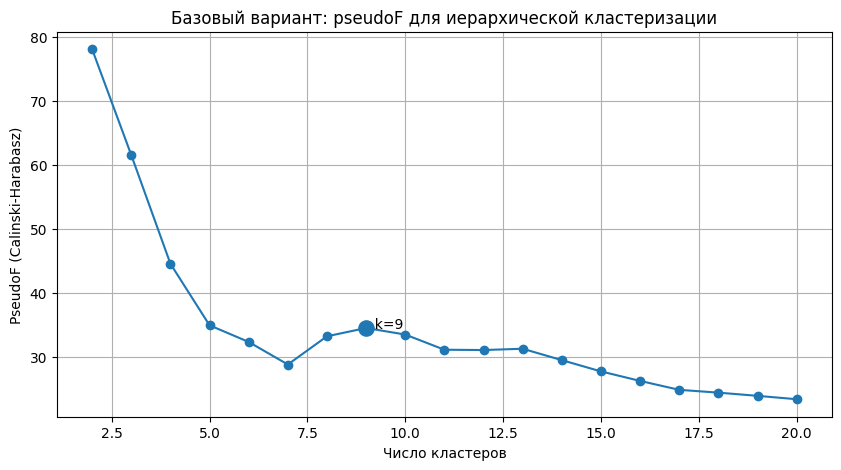

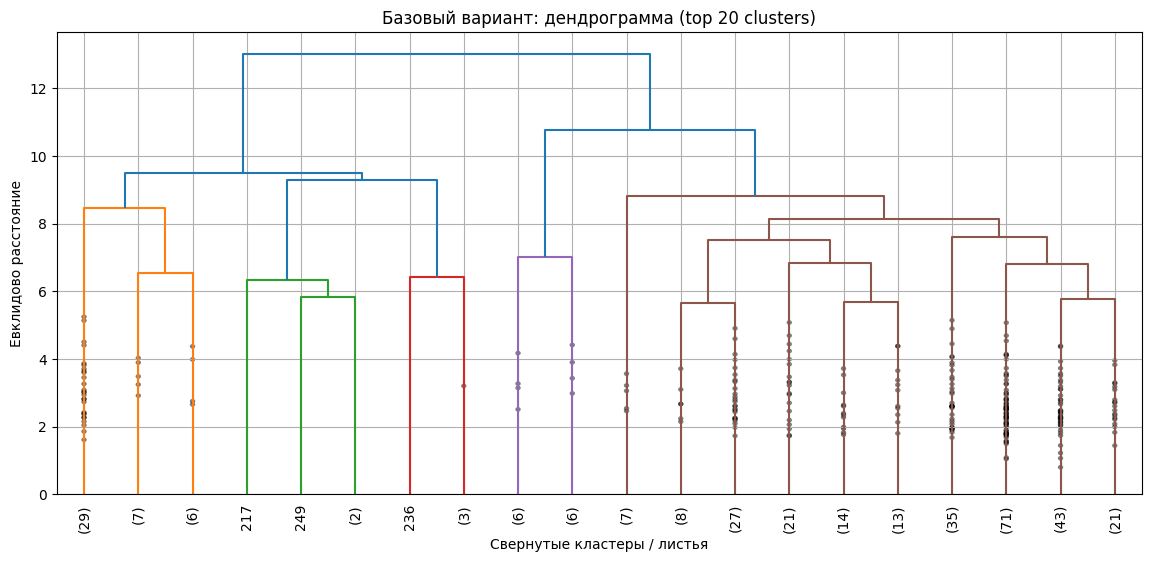

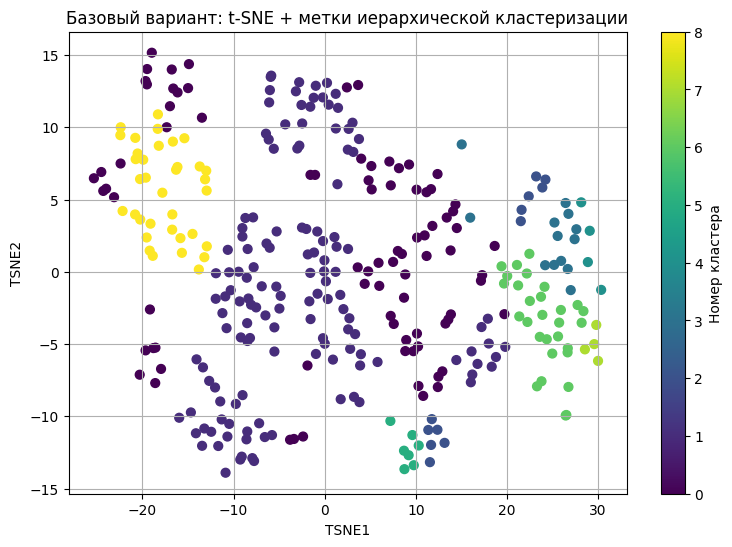

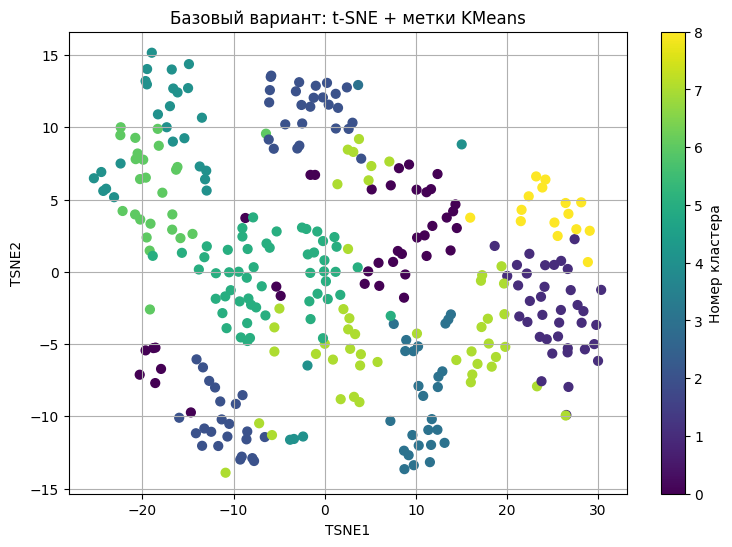


Наиболее типичные представители кластеров (KMeans):
   cluster representative_name  distance_to_centroid
0        0         Davis, Mike              1.927822
1        1    Hendrick, George              2.072125
2        2       Skinner, Joel              1.847660
3        3         Davis, Alan              2.080710
4        4     Bernazard, Tony              2.026166
5        5      Thompson, Milt              1.776263
6        6         Owen, Spike              1.833939
7        7      Herndon, Larry              2.057678
8        8      Winfield, Dave              2.502935


In [6]:
base_analyzer = BaseballClusterAnalyzer(raw_df, id_col="Name", random_state=RANDOM_STATE)
base_results = base_analyzer.run_all()

## Шаг 9. Дополнительная предобработка: логарифмирование скошенных признаков

Используемые числовые признаки:
0        nAtBat
1         nHits
2         nHome
3         nRuns
4          nRBI
5           nBB
6       YrMajor
7       CrAtBat
8        CrHits
9        CrHome
10       CrRuns
11        CrRbi
12         CrBB
13        nOuts
14       nAssts
15       nError
16       Salary
17    logSalary
Name: numeric_feature, dtype: str

Используемые категориальные признаки:
0        Team
1      League
2    Division
3    Position
4         Div
Name: categorical_feature, dtype: str

После кодирования и масштабирования получилось признаков: 75
Оптимальное число кластеров: 4
Правило выбора: first_local_peak
Таблица pseudoF:      k    pseudoF  selected
0    2  53.507763     False
1    3  52.859249     False
2    4  58.913292      True
3    5  53.903236     False
4    6  46.825990     False
5    7  42.141139     False
6    8  38.482248     False
7    9  34.306332     False
8   10  32.662548     False
9   11  31.008731     False
10  12  30.789762     False
11  13  28.986118   

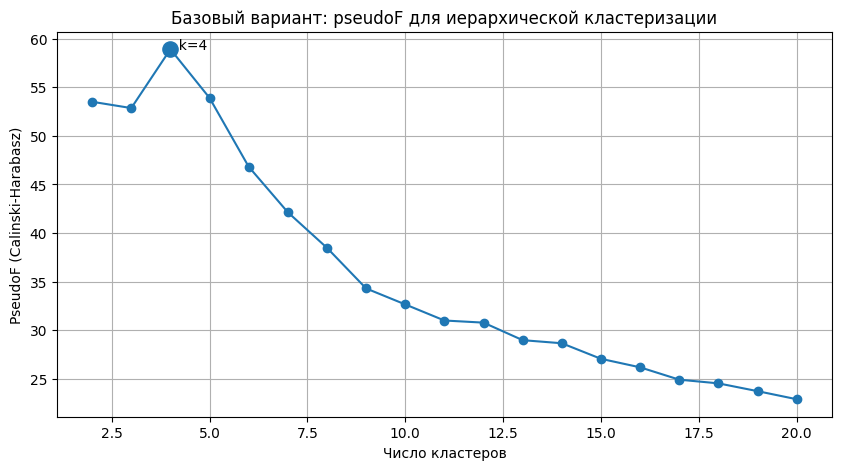

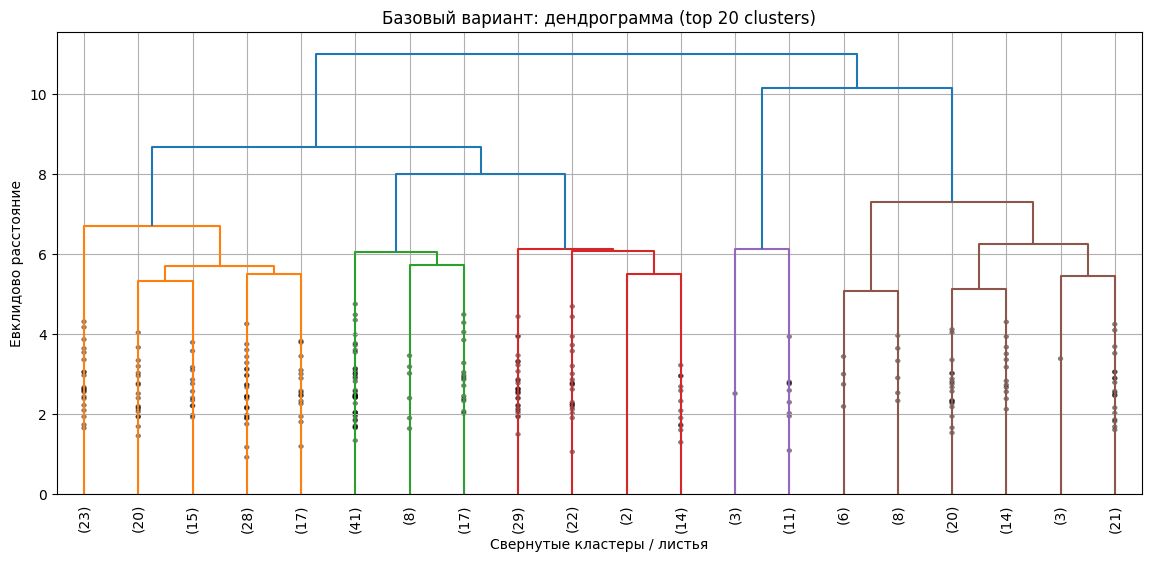

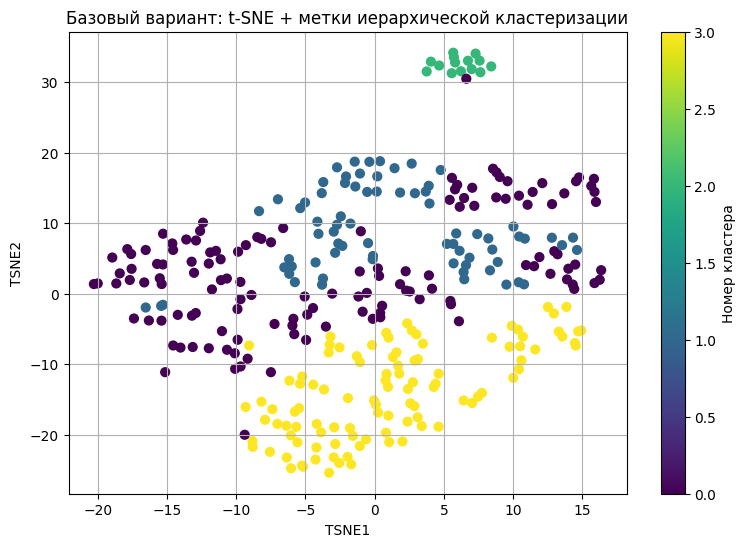

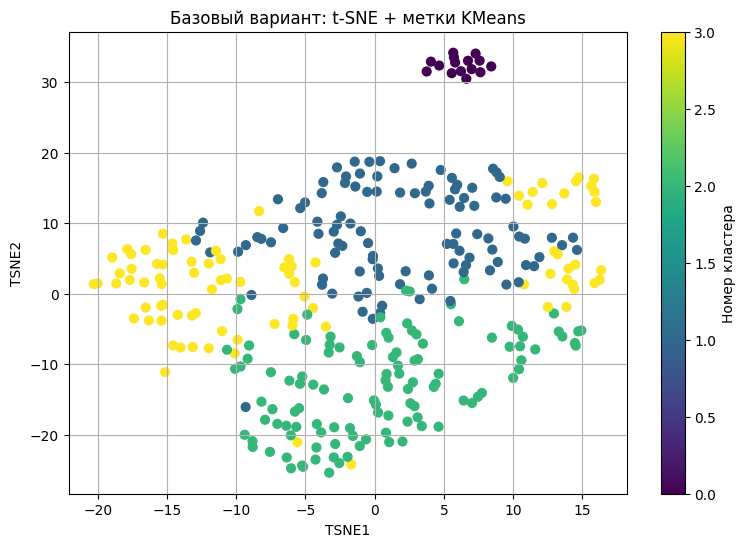


Наиболее типичные представители кластеров (KMeans):
   cluster representative_name  distance_to_centroid
0        0      Thomas, Gorman              1.697796
1        1       Moseby, Lloyd              2.007462
2        2         Salas, Mark              2.139146
3        3      Landreaux, Ken              1.942094


In [7]:
log_analyzer = BaseballClusterAnalyzer(raw_df, id_col="Name", random_state=RANDOM_STATE)
log_results = log_analyzer.run_all(True)

## Шаг 10. Отбор 7 наиболее значимых переменных методом VarClus

['Salary', 'CrAtBat', 'nAssts', 'nHome', 'nHits', 'nBB', 'nOuts']
Используемые числовые признаки:
0     Salary
1    CrAtBat
2     nAssts
3      nHome
4      nHits
5        nBB
6      nOuts
Name: numeric_feature, dtype: str

Используемые категориальные признаки:
Series([], Name: categorical_feature, dtype: object)

После кодирования и масштабирования получилось признаков: 7
Оптимальное число кластеров: 7
Правило выбора: first_local_peak
Таблица pseudoF:      k     pseudoF  selected
0    2  116.139106     False
1    3   77.188934     False
2    4   59.586261     False
3    5   47.387211     False
4    6   61.401913     False
5    7   74.539925      True
6    8   65.266100     False
7    9   62.965979     False
8   10   64.492852     False
9   11   62.395641     False
10  12   60.817446     False
11  13   58.622691     False
12  14   55.976155     False
13  15   61.322722     False
14  16   58.334835     False
15  17   55.780313     False
16  18   55.080418     False
17  19   53.568331   

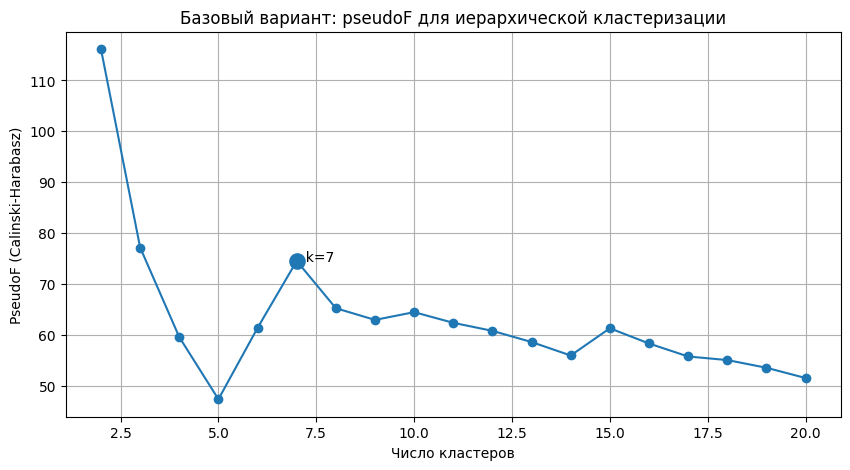

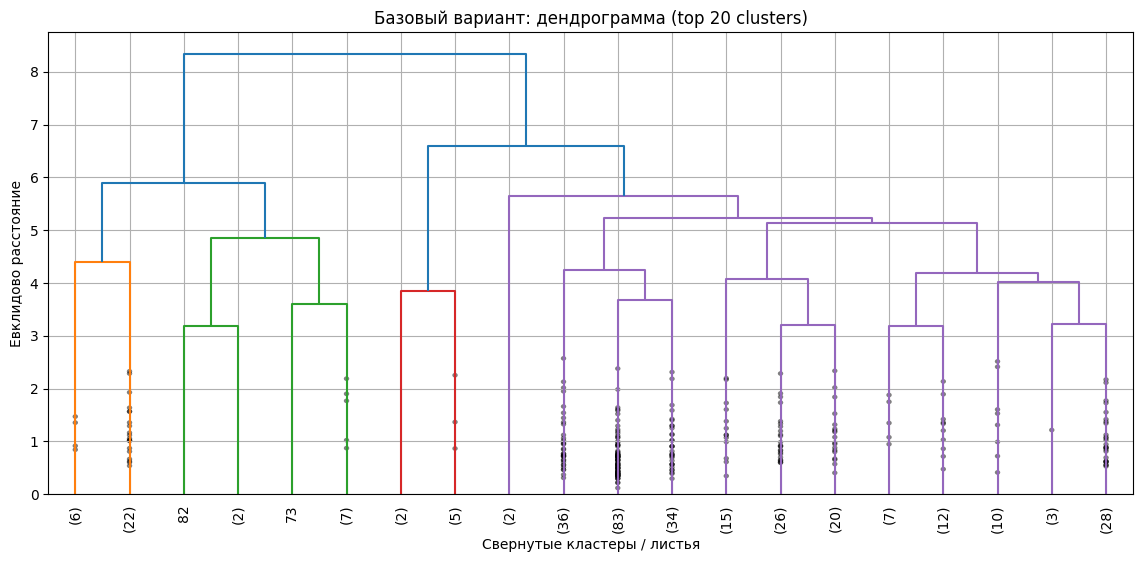

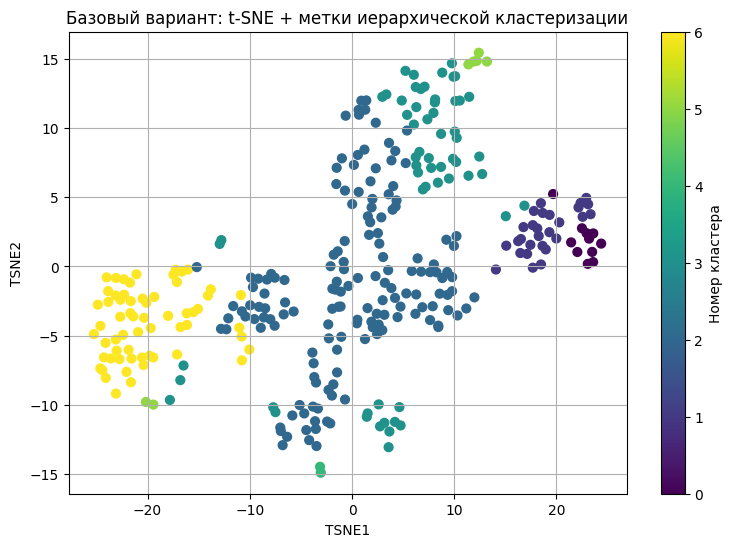

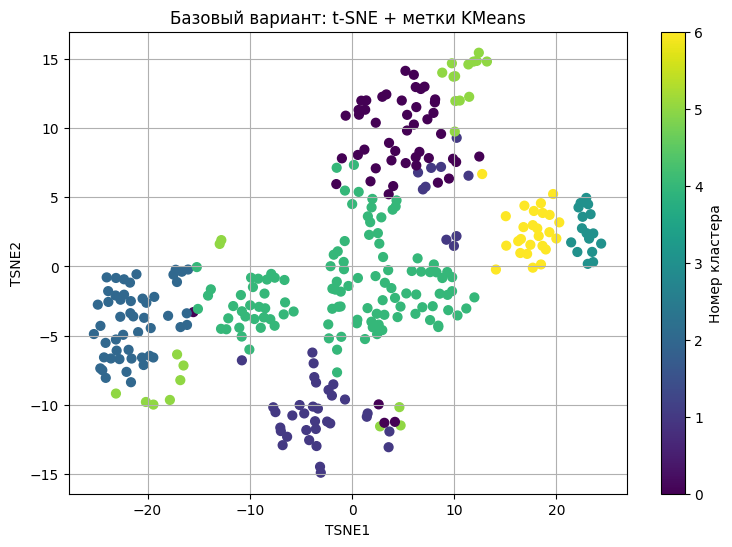


Наиболее типичные представители кластеров (KMeans):
   cluster representative_name  distance_to_centroid
0        0     Van Slyke, Andy              0.637441
1        1        Lopes, Davey              0.636508
2        2     Schofield, Dick              0.568778
3        3        Durham, Leon              0.606604
4        4       Sheridan, Pat              0.484058
5        5    Lansford, Carney              1.218109
6        6        Whitt, Ernie              0.556935


In [12]:
selected_features, varclus_full_table, varclus_selected_table, Z_var = (
    base_analyzer.select_features_varclus_like(n_select=7)
)
print(selected_features)
varclus_analyzer = BaseballClusterAnalyzer(
    raw_df,
    id_col="Name",
    feature_cols=selected_features,
    random_state=RANDOM_STATE
)
varclus_results = varclus_analyzer.run_all()

## Сводное сравнение трех запусков

Сравним:

1. базовый вариант;
2. вариант с дополнительным `log(1+x)` для скошенных признаков;
3. вариант после отбора 7 признаков через VarClus-подобную процедуру.

In [9]:
comparison_df = pd.DataFrame({
    "scenario": [
        "Базовый вариант",
        "Доп. log(1+x) для скошенных признаков",
        "После VarClus-подобного отбора 7 признаков",
    ],
    "optimal_k": [
        base_results["best_k"],
        log_results["best_k"],
        varclus_results["best_k"],
    ],
    "selection_rule": [
        base_results["best_k_rule"],
        log_results["best_k_rule"],
        varclus_results["best_k_rule"],
    ],
    "n_features_after_encoding": [
        base_results["X"].shape[1],
        log_results["X"].shape[1],
        varclus_results["X"].shape[1],
    ],
})

display(comparison_df)

,scenario,optimal_k,selection_rule,n_features_after_encoding
0,Базовый вариант,9,first_local_peak,75
1,Доп. log(1+x) для скошенных признаков,4,first_local_peak,75
2,После VarClus-подобного отбора 7 признаков,7,first_local_peak,7


In [10]:
comparison_reps = pd.concat([
    base_results["representatives"].assign(scenario="Базовый вариант"),
    log_results["representatives"].assign(scenario="Доп. log(1+x)"),
    varclus_results["representatives"].assign(scenario="После VarClus"),
], ignore_index=True)

display(comparison_reps)

,cluster,representative_name,distance_to_centroid,scenario
0,0,"Davis, Mike",1.927822,Базовый вариант
1,1,"Hendrick, George",2.072125,Базовый вариант
2,2,"Skinner, Joel",1.847660,Базовый вариант
3,3,"Davis, Alan",2.080710,Базовый вариант
4,4,"Bernazard, Tony",2.026166,Базовый вариант
5,5,"Thompson, Milt",1.776263,Базовый вариант
6,6,"Owen, Spike",1.833939,Базовый вариант
7,7,"Herndon, Larry",2.057678,Базовый вариант
8,8,"Winfield, Dave",2.502935,Базовый вариант
9,0,"Thomas, Gorman",1.697796,Доп. log(1+x)
